In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy import signal
import xarray as xr
import sys
sys.path.append("/home/563/clv563/Winter_school_2024/")
import wavenumber_frequency_functions as wf
from scipy.signal import convolve2d, detrend
import glob as glob

In [3]:
from dask.distributed import Client, LocalCluster 
cluster = LocalCluster(n_workers=14, memory_limit="9GiB") 
c = Client(cluster)
c

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:33203
INFO:distributed.scheduler:  dashboard at:         /proxy/8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:38785'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40611'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:46515'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:33109'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:43183'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40249'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:33539'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41143'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:33337'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:38435'
INFO:distributed.nanny:        Start Nanny at: 'tcp

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 14
Total threads: 14,Total memory: 126.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33203,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44827,Total threads: 1
Dashboard: /proxy/41547/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:38785,


INFO:distributed.core:Event loop was unresponsive in Nanny for 3.01s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 3.01s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 3.01s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 3.06s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 3.06s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts an

In [4]:
#fname = '/scratch/v46/clv563/ACCESS_AM3_tmp/am3a.pa2008apr.nc'
#fname =  np.sort(glob.glob('/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008*.nc'))
fname = ['/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008jan.nc',
 '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008feb.nc',
 '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008mar.nc',
 '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008apr.nc',
 '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008may.nc',
 '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008jun.nc',
 '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008jul.nc',
 '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008aug.nc',
 '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008sep.nc',
 '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008oct.nc',
 '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008nov.nc',
 '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008dec.nc']
print(fname)
ds = xr.open_mfdataset(fname, combine = 'nested', concat_dim = 'time_0')

OLR = ds.fld_s02i205
OLR_rn = OLR.rename({"time_0": "time"})
OLR_rn_daily_n96 = OLR_rn.resample(time='1D').mean('time')


['/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008jan.nc', '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008feb.nc', '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008mar.nc', '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008apr.nc', '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008may.nc', '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008jun.nc', '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008jul.nc', '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008aug.nc', '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008sep.nc', '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008oct.nc', '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008nov.nc', '/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008dec.nc']


/jobfs/169914341.gadi-pbs/ipykernel_1242788/1873993890.py:16: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset(fname, combine = 'nested', concat_dim = 'time_0')
/jobfs/169914341.gadi-pbs/ipykernel_1242788/1873993890.py:16: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(fname, combine = 'nested

In [5]:
#fname = '/scratch/v46/clv563/ACCESS_AM3_tmp/am3a.pa2008apr.nc'
#fname =  np.sort(glob.glob('/g/data/gb02/public/AM3/output/control/n96/am3a.pa2008*.nc'))
fname = ['/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008jan.nc',
 '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008feb.nc',
 '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008mar.nc',
 '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008apr.nc',
 '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008may.nc',
 '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008jun.nc',
 '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008jul.nc',
 '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008aug.nc',
 '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008sep.nc',
 '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008oct.nc',
 '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008nov.nc',
 '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008dec.nc']
print(fname)
ds = xr.open_mfdataset(fname, combine = 'nested', concat_dim = 'time_0')

OLR = ds.fld_s02i205
OLR_rn = OLR.rename({"time_0": "time"})
OLR_rn_daily_n512 = OLR_rn.resample(time='1D').mean('time')

['/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008jan.nc', '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008feb.nc', '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008mar.nc', '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008apr.nc', '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008may.nc', '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008jun.nc', '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008jul.nc', '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008aug.nc', '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008sep.nc', '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008oct.nc', '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008nov.nc', '/g/data/gb02/public/AM3/output/control/n512/test2a.pa2008dec.nc']


/jobfs/169914341.gadi-pbs/ipykernel_1242788/1348298457.py:16: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset(fname, combine = 'nested', concat_dim = 'time_0')
/jobfs/169914341.gadi-pbs/ipykernel_1242788/1348298457.py:16: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(fname, combine = 'nested

In [6]:
# Data downloaded from: https://downloads.psl.noaa.gov/Datasets/interp_OLR/
fname = '/g/data/w40/clv563/OLR/olr.day.mean.nc'
ds_obs = xr.open_dataset(fname)
data_missing = ds_obs['olr']
data_all = data_missing.interpolate_na(dim="time", method="linear")

In [7]:
OLR_obs_2018 = data_all.sel(time = data_all.time.dt.year == 2018)

In [8]:
latBound = (-15,15)  # latitude bounds for analysis
spd      = 1    # SAMPLES PER DAY
nDayWin  = 96   # Wheeler-Kiladis [WK] temporal window length (days)
nDaySkip = -65  # time (days) between temporal windows [segments]
                    # negative means there will be overlapping temporal segments
twoMonthOverlap = 65
opt      = {'segsize': nDayWin, 
                'noverlap': twoMonthOverlap, 
                'spd': spd, 
                'latitude_bounds': latBound, 
                'dosymmetries': True, 
                'rmvLowFrq':True}

z2 = wf.spacetime_power(OLR_rn_daily_n96, **opt)
z2avg = z2.mean(dim='component')
z2.loc[{'frequency':0}] = np.nan # get rid of spurious power at \nu = 0
# the background is supposed to be derived from both symmetric & antisymmetric
background = wf.smooth_wavefreq(z2avg, kern=wf.simple_smooth_kernel(), nsmooth=50, freq_name='frequency')
# separate components
z2_sym = z2[0,...]
z2_asy = z2[1,...]
# normalize
nspec_sym_n96 = z2_sym / background 
nspec_asy_n96 = z2_asy / background

INFO:root:Data reduced by latitude bounds. Size is Frozen({'time': 360, 'lat': 24, 'lon': 192})


<xarray.DataArray 'fld_s02i205' (time: 360, lat: 24, lon: 192)> Size: 7MB
dask.array<getitem, shape=(360, 24, 192), dtype=float32, chunksize=(1, 24, 192), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) datetime64[ns] 3kB 2007-06-16 2007-06-17 ... 2008-06-09
  * lat       (lat) float64 192B -14.38 -13.12 -11.88 ... 11.88 13.12 14.38
  * lon       (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height    float64 8B 10.0
    height_0  float64 8B 1.5
Attributes:
    standard_name:    toa_outgoing_longwave_flux
    long_name:        OUTGOING LW RAD FLUX (TOA)
    units:            W m-2
    grid_mapping:     latitude_longitude
    um_stash_source:  m01s02i205
    cell_methods:     time_0: mean


INFO:root:No missing, so use simplest segment detrend.
INFO:root:[Hayashi] input dims is ('time', 'lat', 'wavenumber', 'frequency'), (9, 24, 192, 96)
INFO:root:[Hayashi] input coords is Coordinates:
  * time        (time) datetime64[ns] 72B 2007-09-19 2007-10-20 ... 2008-05-24
  * lat         (lat) float64 192B -14.38 -13.12 -11.88 ... 11.88 13.12 14.38
  * wavenumber  (wavenumber) float64 2kB 0.0 1.0 2.0 3.0 ... -4.0 -3.0 -2.0 -1.0
  * frequency   (frequency) float64 768B 0.0 0.01042 ... -0.02083 -0.01042


(9, 24, 193, 97)
freq size is (97,).


In [9]:
latBound = (-15,15)  # latitude bounds for analysis
spd      = 1    # SAMPLES PER DAY
nDayWin  = 96   # Wheeler-Kiladis [WK] temporal window length (days)
nDaySkip = -65  # time (days) between temporal windows [segments]
                    # negative means there will be overlapping temporal segments
twoMonthOverlap = 65
opt      = {'segsize': nDayWin, 
                'noverlap': twoMonthOverlap, 
                'spd': spd, 
                'latitude_bounds': latBound, 
                'dosymmetries': True, 
                'rmvLowFrq':True}

z2 = wf.spacetime_power(OLR_rn_daily_n512, **opt)
z2avg = z2.mean(dim='component')
z2.loc[{'frequency':0}] = np.nan # get rid of spurious power at \nu = 0
# the background is supposed to be derived from both symmetric & antisymmetric
background = wf.smooth_wavefreq(z2avg, kern=wf.simple_smooth_kernel(), nsmooth=50, freq_name='frequency')
# separate components
z2_sym = z2[0,...]
z2_asy = z2[1,...]
# normalize
nspec_sym_n512 = z2_sym / background 
nspec_asy_n512 = z2_asy / background

INFO:root:Data reduced by latitude bounds. Size is Frozen({'time': 360, 'lat': 128, 'lon': 1024})


<xarray.DataArray 'fld_s02i205' (time: 360, lat: 128, lon: 1024)> Size: 189MB
dask.array<getitem, shape=(360, 128, 1024), dtype=float32, chunksize=(1, 128, 1024), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) datetime64[ns] 3kB 2007-06-16 2007-06-17 ... 2008-06-09
  * lat       (lat) float64 1kB -14.88 -14.65 -14.41 ... 14.41 14.65 14.88
  * lon       (lon) float64 8kB 0.1758 0.5273 0.8789 1.23 ... 359.1 359.5 359.8
    height    float64 8B 10.0
    height_0  float64 8B 1.5
Attributes:
    standard_name:    toa_outgoing_longwave_flux
    long_name:        OUTGOING LW RAD FLUX (TOA)
    units:            W m-2
    grid_mapping:     latitude_longitude
    um_stash_source:  m01s02i205
    cell_methods:     time_0: mean


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 180.51 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
INFO:root:No missing, so use simplest segment detrend.
INFO:root:[Hayashi] input dims is ('time', 'lat', 'wavenumber', 'frequency'), (9, 128, 1024, 96)
INFO:root:[Hayashi] input coords is Coordinates:
  * time        (time) datetime64[ns] 72B 2007-09-19 2007-10-20 ... 2008-05-24
  * lat         (lat) float64 1kB -14.88 -14.65 -14.41 ... 14.41 14.65 14.88
  * wavenumber  (wavenumber) float64 8kB 0.0 1.0 2.0 3.0 ... -4.0 -3.0 -2.0 -1.0
  * frequency   (frequency) float64 768B 0.0 0.01042 ... -0.02083 -0.01042


(9, 128, 1025, 97)
freq size is (97,).


In [10]:
latBound = (15,-15)  # latitude bounds for analysis
spd      = 1    # SAMPLES PER DAY
nDayWin  = 96   # Wheeler-Kiladis [WK] temporal window length (days)
nDaySkip = -65  # time (days) between temporal windows [segments]
                    # negative means there will be overlapping temporal segments
twoMonthOverlap = 65
opt      = {'segsize': nDayWin, 
                'noverlap': twoMonthOverlap, 
                'spd': spd, 
                'latitude_bounds': latBound, 
                'dosymmetries': True, 
                'rmvLowFrq':True}

z2 = wf.spacetime_power(OLR_obs_2018, **opt)
z2avg = z2.mean(dim='component')
z2.loc[{'frequency':0}] = np.nan # get rid of spurious power at \nu = 0
# the background is supposed to be derived from both symmetric & antisymmetric
background = wf.smooth_wavefreq(z2avg, kern=wf.simple_smooth_kernel(), nsmooth=50, freq_name='frequency')
# separate components
z2_sym = z2[0,...]
z2_asy = z2[1,...]
# normalize
nspec_sym_obs = z2_sym / background 
nspec_asy_obs = z2_asy / background

INFO:root:Data reduced by latitude bounds. Size is Frozen({'time': 365, 'lat': 13, 'lon': 144})
INFO:root:No missing, so use simplest segment detrend.


<xarray.DataArray 'olr' (time: 365, lat: 13, lon: 144)> Size: 3MB
array([[[277.5 , 276.  , 274.  , ..., 271.5 , 268.  , 272.5 ],
        [278.75, 276.25, 276.  , ..., 272.6 , 273.5 , 275.7 ],
        [279.5 , 276.5 , 275.  , ..., 273.5 , 276.5 , 278.75],
        ...,
        [237.5 , 254.  , 262.5 , ..., 264.5 , 252.5 , 243.5 ],
        [241.25, 257.6 , 263.75, ..., 267.1 , 248.75, 232.2 ],
        [247.  , 262.25, 265.5 , ..., 261.5 , 258.5 , 261.5 ]],

       [[245.5 , 258.75, 272.  , ..., 262.25, 216.  , 249.25],
        [272.75, 269.6 , 271.5 , ..., 271.75, 252.  , 266.25],
        [278.5 , 275.75, 279.5 , ..., 278.  , 272.5 , 277.25],
        ...,
        [245.5 , 258.75, 270.5 , ..., 268.25, 263.5 , 253.25],
        [249.75, 259.35, 267.5 , ..., 262.1 , 233.  , 244.1 ],
        [241.  , 264.75, 269.  , ..., 257.5 , 247.  , 249.75]],

       [[222.  , 224.5 , 250.5 , ..., 202.  , 204.5 , 243.5 ],
        [252.  , 270.6 , 273.5 , ..., 250.85, 250.5 , 257.35],
        [278.  , 274. 

INFO:root:[Hayashi] input dims is ('time', 'lat', 'wavenumber', 'frequency'), (9, 13, 144, 96)
INFO:root:[Hayashi] input coords is Coordinates:
  * time        (time) datetime64[ns] 72B 2018-04-06 2018-05-07 ... 2018-12-10
  * lat         (lat) float32 52B 15.0 12.5 10.0 7.5 ... -7.5 -10.0 -12.5 -15.0
  * wavenumber  (wavenumber) float64 1kB 0.0 1.0 2.0 3.0 ... -4.0 -3.0 -2.0 -1.0
  * frequency   (frequency) float64 768B 0.0 0.01042 ... -0.02083 -0.01042


(9, 13, 145, 97)
freq size is (97,).


In [11]:
def plot_normalized_symmetric_spectrum(s, ofil=None):
    """Basic plot of normalized symmetric power spectrum with shallow water curves."""
    fb = [0, .5]  # frequency bounds for plot
    # get data for dispersion curves:
    swfreq,swwn = wf.genDispersionCurves()
    # swfreq.shape # -->(6, 3, 50)
    swf = np.where(swfreq == 1e20, np.nan, swfreq)
    swk = np.where(swwn == 1e20, np.nan, swwn)

    fig, ax = plt.subplots()
    c = 'darkgray' # COLOR FOR DISPERSION LINES/LABELS
    z = s.transpose().sel(frequency=slice(*fb), wavenumber=slice(-15,15))
    z.loc[{'frequency':0}] = np.nan
    kmesh0, vmesh0 = np.meshgrid(z['wavenumber'], z['frequency'])
    img = ax.contourf(kmesh0, vmesh0, z, levels=np.linspace(0.2, 3.0, 16), cmap='Spectral_r',  extend='both')
    for ii in range(3,6):
        ax.plot(swk[ii, 0,:], swf[ii,0,:], color=c)
        ax.plot(swk[ii, 1,:], swf[ii,1,:], color=c)
        ax.plot(swk[ii, 2,:], swf[ii,2,:], color=c)
    ax.axvline(0, linestyle='dashed', color='lightgray')
    ax.set_xlim([-15,15])
    ax.set_ylim(fb)    
    ax.set_xlabel('Zonal Wavenumber')
    ax.set_ylabel('Frequency [cycles per day]')
    ax.set_title("Normalized Symmetric Component")
    fig.colorbar(img)
    if ofil is not None:
        fig.savefig(ofil, bbox_inches='tight', dpi=144)

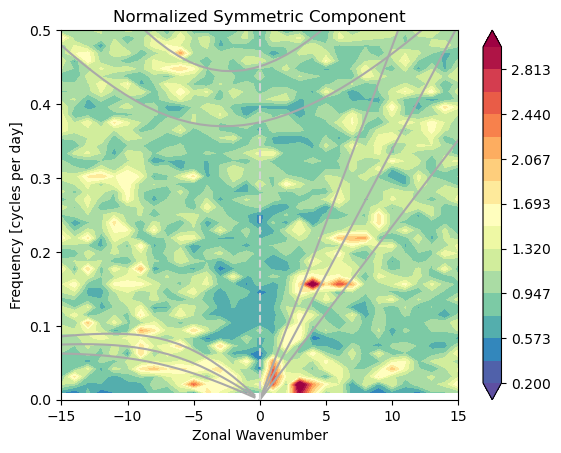

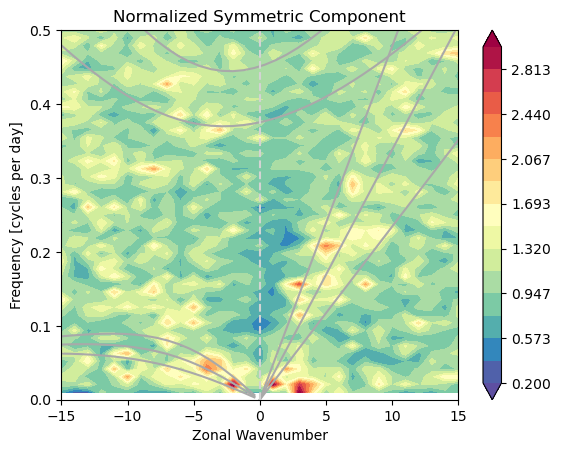

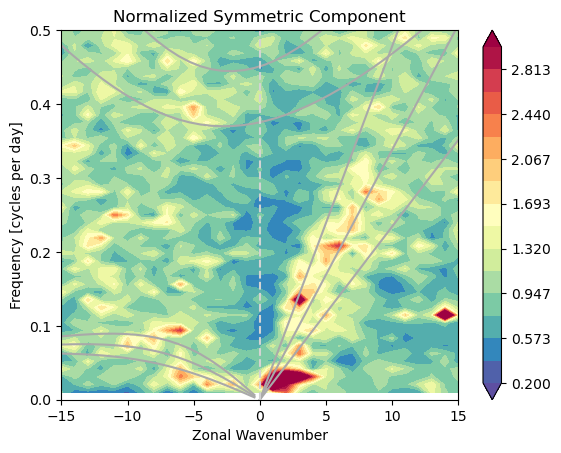

ERROR:tornado.application:Uncaught exception GET /individual-workers-memory/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='gadi-hmem-bdw-0007.gadi.nci.org.au:40730', method='GET', uri='/individual-workers-memory/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/tornado/web.py", line 3409, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Confi

In [12]:
outPlotName = "test_symmetric_plot.png"
plot_normalized_symmetric_spectrum(nspec_sym_n96, outPlotName)

outPlotName = "test_symmetric_plot.png"
plot_normalized_symmetric_spectrum(nspec_sym_n512, outPlotName)

outPlotName = "test_symmetric_plot.png"
plot_normalized_symmetric_spectrum(nspec_sym_obs, outPlotName)

In [11]:
OLR_tropics = OLR_rn.sel(lat=slice(-15,15)).load()

In [12]:
OLR_tropics

<xarray.DataArray 'fld_s02i205' (time: 2880, lat: 24, lon: 192)> Size: 53MB
array([[[280.65228, 278.51587, 271.9179 , ..., 283.45963, 283.42572,
         281.89175],
        [280.70572, 278.374  , 259.79407, ..., 282.30396, 283.70526,
         282.44852],
        [270.05185, 269.1423 , 248.28273, ..., 283.9778 , 283.44476,
         278.46344],
        ...,
        [282.17047, 280.01242, 287.3767 , ..., 285.8778 , 289.21176,
         288.45126],
        [263.96252, 250.03352, 266.16684, ..., 268.77173, 284.42776,
         283.2875 ],
        [239.48285, 237.33177, 257.29602, ..., 261.78058, 245.81787,
         228.09235]],

       [[278.51334, 277.207  , 268.91986, ..., 281.54276, 282.0514 ,
         281.311  ],
        [280.21228, 269.0892 , 259.71396, ..., 283.40967, 282.9107 ,
         281.46603],
        [268.76175, 267.6038 , 251.90749, ..., 283.64243, 281.96014,
         279.86713],
...
        [228.89105, 259.64014, 278.44202, ..., 237.38335, 222.27725,
         226.30244],
        [246.82355, 261.04324, 278.36676, ..., 202.52629, 230.53242,
         238.25995],
        [275.71622, 277.12097, 277.1294 , ..., 219.89905, 250.35907,
         267.9489 ]],

       [[268.6045 , 265.84845, 251.91702, ..., 292.65323, 289.699  ,
         281.8243 ],
        [265.8164 , 262.28406, 238.37599, ..., 283.491  , 278.14307,
         269.45392],
        [266.6428 , 273.06458, 262.4856 , ..., 291.10938, 285.77487,
         281.6972 ],
        ...,
        [255.2932 , 256.48785, 263.03732, ..., 268.5841 , 259.4228 ,
         257.7678 ],
        [228.26114, 256.8736 , 272.8699 , ..., 232.8952 , 211.87347,
         204.182  ],
        [257.99228, 267.3154 , 270.78824, ..., 189.51862, 194.87022,
         226.60884]]], shape=(2880, 24, 192), dtype=float32)
Coordinates:
  * time      (time) datetime64[ns] 23kB 2007-06-16T01:30:00 ... 2008-06-09T2...
  * lat       (lat) float64 192B -14.38 -13.12 -11.88 ... 11.88 13.12 14.38
  * lon       (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height    float64 8B 10.0
    height_0  float64 8B 1.5
Attributes:
    standard_name:    toa_outgoing_longwave_flux
    long_name:        OUTGOING LW RAD FLUX (TOA)
    units:            W m-2
    grid_mapping:     latitude_longitude
    um_stash_source:  m01s02i205
    cell_methods:     time_0: mean

In [13]:
Pxx = np.empty([192, 1461])
for lon in np.arange(0,192):
    f, Pxx[lon, :] = signal.periodogram(OLR_tropics[:,0,lon], 8, window='hann',nfft=365 * 8)

In [16]:
np.max(f)

np.float64(4.0)

Text(0, 0.5, 'Pxx')

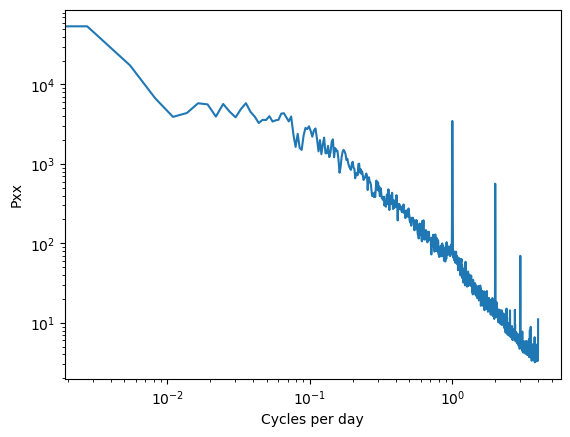

In [14]:
plt.loglog(f, Pxx.mean(axis=0))
plt.xlabel('Cycles per day')
plt.ylabel('Pxx')

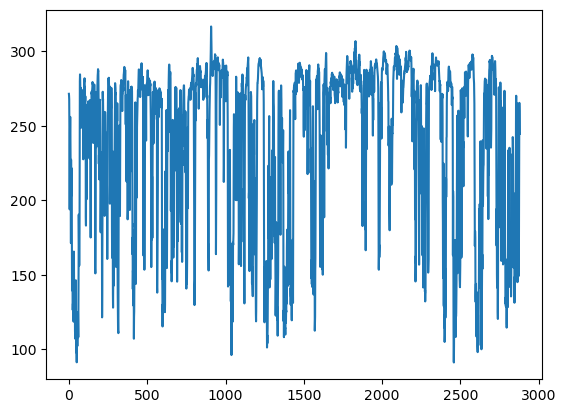

In [15]:
plt.plot(OLR_tropics[:,0,100])